# Car Price Prediction using Random Forest Regressor
## Project Overview
    The aim of this Data Science Project to focuses on building a machine learning model to predict car price for a company in Poland. Identifying car price by their model, generation, year of production, mileage, localization, and type and volume of engine.


In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

## Variables:
 ### Price:
    Price variable shows the cost of car in Poland currency PLN (approx. 1USD=1PLN)
### Unnamed: 0:
    It represent the serial number.
### mark:
    Mark of the car.
### model:
     Model of the car.
### generation_name:
Formatted Generation Name of the car.
### year:
Car Year of formatted.
### mileage:
Car Mileage in Kilometres.
### vol_engine:
Auto Engine Size.
### fuel:
Represent Engine Type according to their fuel type.
### city:
Locality in Poland.
### province:
Region of Poland.

In [6]:
df = pd.read_csv("/kaggle/input/datasets/aleksandrglotov/car-prices-poland/Car_Prices_Poland_Kaggle.csv")
df.head()

,Unnamed: 0,mark,model,generation_name,year,mileage,vol_engine,fuel,city,province,price
0,0,opel,combo,gen-d-2011,2015,139568,1248,Diesel,Janki,Mazowieckie,35900
1,1,opel,combo,gen-d-2011,2018,31991,1499,Diesel,Katowice,Śląskie,78501
2,2,opel,combo,gen-d-2011,2015,278437,1598,Diesel,Brzeg,Opolskie,27000
3,3,opel,combo,gen-d-2011,2016,47600,1248,Diesel,Korfantów,Opolskie,30800
4,4,opel,combo,gen-d-2011,2014,103000,1400,CNG,Tarnowskie Góry,Śląskie,35900


## drop irralivant feature

In [7]:

df.drop("Unnamed: 0",axis=1, inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117927 entries, 0 to 117926
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   mark             117927 non-null  object
 1   model            117927 non-null  object
 2   generation_name  87842 non-null   object
 3   year             117927 non-null  int64 
 4   mileage          117927 non-null  int64 
 5   vol_engine       117927 non-null  int64 
 6   fuel             117927 non-null  object
 7   city             117927 non-null  object
 8   province         117927 non-null  object
 9   price            117927 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 9.0+ MB


## drop all the null and duplicated values

In [9]:

df.dropna(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(5046)

In [11]:
#drop all the duplicatted values
df.drop_duplicates(inplace=True)

In [12]:

df.describe().astype(int)

,year,mileage,vol_engine,price
count,82796,82796,82796,82796
mean,2012,152751,1842,62598
std,5,89996,613,75624
min,1978,0,0,900
25%,2008,86338,1498,19900
50%,2012,158700,1798,37900
75%,2017,212316,1995,73850
max,2022,2500000,6600,2399900


In [13]:
#for numaric colmuns
colmuns = df.select_dtypes(include='number')

In [14]:
colmuns

,year,mileage,vol_engine,price
0,2015,139568,1248,35900
1,2018,31991,1499,78501
2,2015,278437,1598,27000
3,2016,47600,1248,30800
4,2014,103000,1400,35900
...,...,...,...,...
117250,2017,51000,1969,229900
117251,2016,83500,1969,135000
117252,2017,174000,1969,154500
117253,2016,189020,1969,130000


In [15]:
import seaborn as sns 

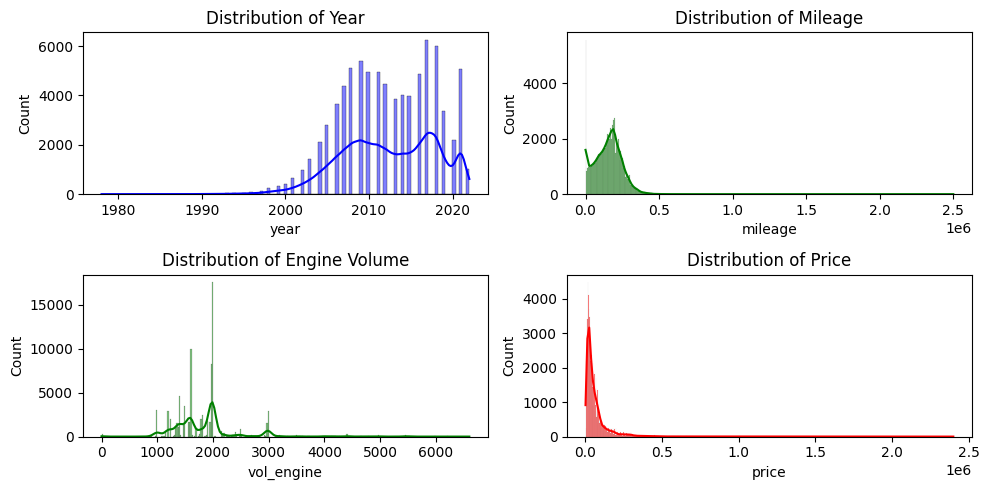

In [16]:
fig, axes= plt.subplots(2,2, figsize=(10,5))

sns.histplot(data=df, x='year', kde=True, color="blue", edgecolor="black",ax=axes[0,0])
axes[0, 0].set_title('Distribution of Year')


sns.histplot(data=df, x='mileage', kde=True, color="green", edgecolor="black",ax=axes[0,1]) 
axes[0, 1].set_title('Distribution of Mileage')


sns.histplot(data=df, x='vol_engine', kde=True, color="green", edgecolor="black",ax=axes[1,0])
axes[1, 0].set_title('Distribution of Engine Volume')


sns.histplot(data=df, x='price', kde=True, color="red", edgecolor="black",ax=axes[1,1])
axes[1, 1].set_title('Distribution of Price')


plt.tight_layout()

plt.show()

In [17]:
def remove_outliers(df, column):
   
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    num_outliers = len(df) - len(df_filtered)
    print(f"\n--- Outlier Removal Summary for '{column}' ---")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Original rows: {len(df)}, Filtered rows: {len(df_filtered)}")
    print(f"Number of outliers removed: {num_outliers}")

    return df_filtered

In [18]:
for col in colmuns: 
    df=remove_outliers(df, col)


--- Outlier Removal Summary for 'year' ---
Q1: 2008.00, Q3: 2017.00, IQR: 9.00
Lower Bound: 1994.50, Upper Bound: 2030.50
Original rows: 82796, Filtered rows: 82645
Number of outliers removed: 151

--- Outlier Removal Summary for 'mileage' ---
Q1: 86180.00, Q3: 212021.00, IQR: 125841.00
Lower Bound: -102581.50, Upper Bound: 400782.50
Original rows: 82645, Filtered rows: 82228
Number of outliers removed: 417

--- Outlier Removal Summary for 'vol_engine' ---
Q1: 1498.00, Q3: 1995.00, IQR: 497.00
Lower Bound: 752.50, Upper Bound: 2740.50
Original rows: 82228, Filtered rows: 75046
Number of outliers removed: 7182

--- Outlier Removal Summary for 'price' ---
Q1: 19500.00, Q3: 68899.00, IQR: 49399.00
Lower Bound: -54598.50, Upper Bound: 142997.50
Original rows: 75046, Filtered rows: 69488
Number of outliers removed: 5558


<b style="font-family: 'Times New Roman'; font-size: 20px; display: block;">After removed the outlier</b>

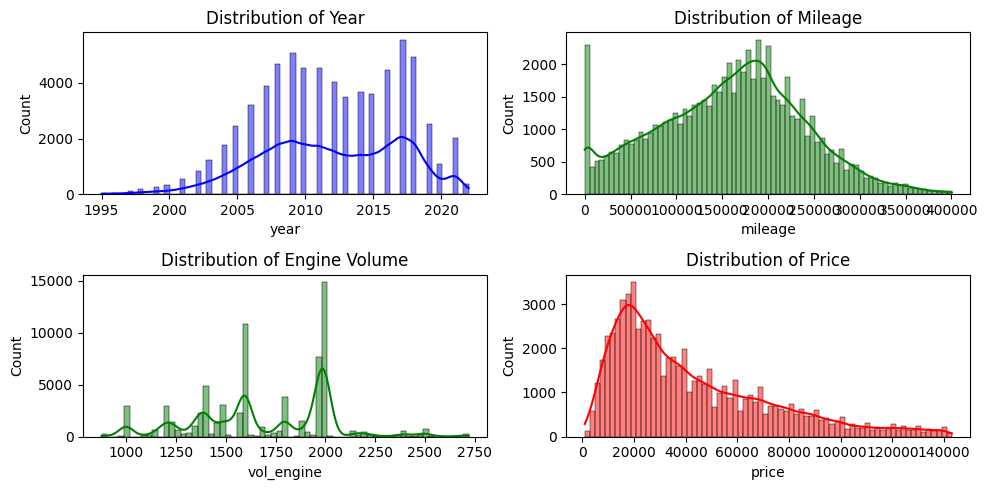

In [19]:
fig, axes= plt.subplots(2,2, figsize=(10,5))

sns.histplot(data=df, x='year', kde=True, color="blue", edgecolor="black",ax=axes[0,0])
axes[0, 0].set_title('Distribution of Year')


sns.histplot(data=df, x='mileage', kde=True, color="green", edgecolor="black",ax=axes[0,1]) 
axes[0, 1].set_title('Distribution of Mileage')


sns.histplot(data=df, x='vol_engine', kde=True, color="green", edgecolor="black",ax=axes[1,0])
axes[1, 0].set_title('Distribution of Engine Volume')


sns.histplot(data=df, x='price', kde=True, color="red", edgecolor="black",ax=axes[1,1])
axes[1, 1].set_title('Distribution of Price')


plt.tight_layout()

plt.show()

In [20]:
df.describe()

,year,mileage,vol_engine,price
count,69488.000000,69488.000000,69488.000000,69488.000000
mean,2011.855961,159203.062716,1686.756131,42062.148788
std,5.141381,79948.075522,337.784631,30519.505297
min,1995.000000,1.000000,875.000000,900.000000
25%,2008.000000,102392.500000,1399.000000,18800.000000
50%,2012.000000,165000.000000,1598.000000,32900.000000
75%,2016.000000,212900.000000,1984.000000,59600.000000
max,2022.000000,400500.000000,2720.000000,142990.000000


In [21]:
# to getting text carring colmuns
text_columns = df.select_dtypes(include='object')

In [22]:
text_columns

,mark,model,generation_name,fuel,city,province
0,opel,combo,gen-d-2011,Diesel,Janki,Mazowieckie
1,opel,combo,gen-d-2011,Diesel,Katowice,Śląskie
2,opel,combo,gen-d-2011,Diesel,Brzeg,Opolskie
3,opel,combo,gen-d-2011,Diesel,Korfantów,Opolskie
4,opel,combo,gen-d-2011,CNG,Tarnowskie Góry,Śląskie
...,...,...,...,...,...,...
117230,volvo,xc-90,gen-ii-2014-xc-90,Diesel,Wrocław,Dolnośląskie
117237,volvo,xc-90,gen-ii-2014-xc-90,Gasoline,Warszawa,Mazowieckie
117251,volvo,xc-90,gen-ii-2014-xc-90,Gasoline,Pruszcz Gdański,Pomorskie
117253,volvo,xc-90,gen-ii-2014-xc-90,Gasoline,Sionna,Mazowieckie


## To know the Quantity of objects feature

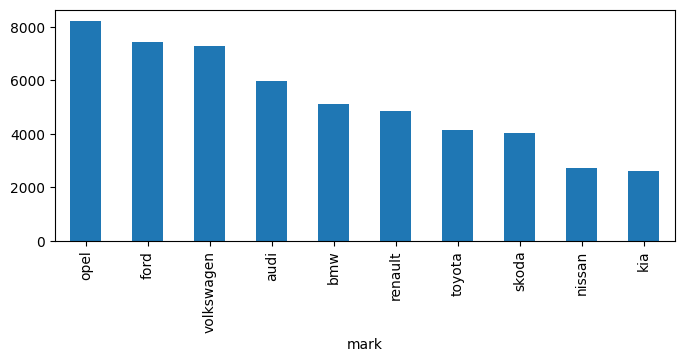

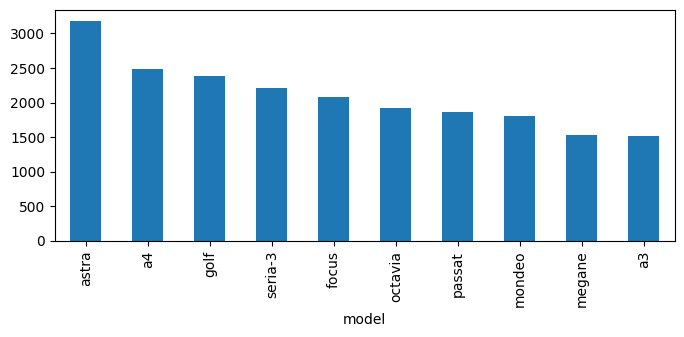

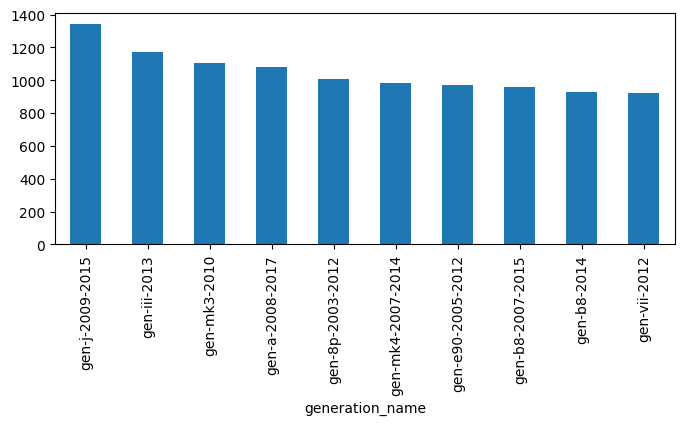

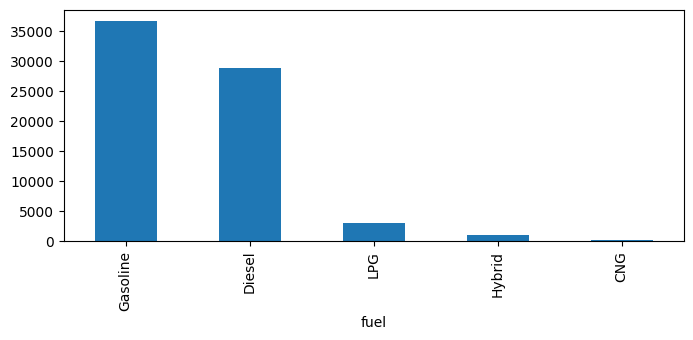

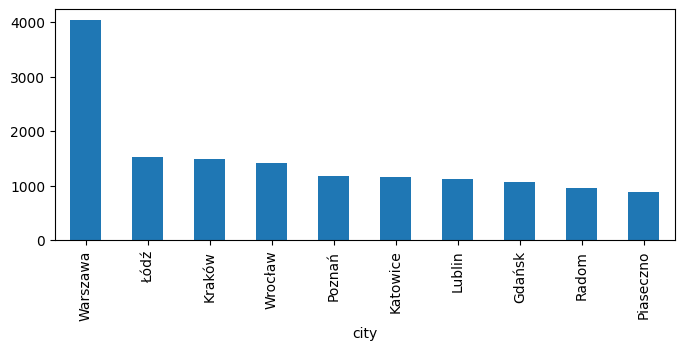

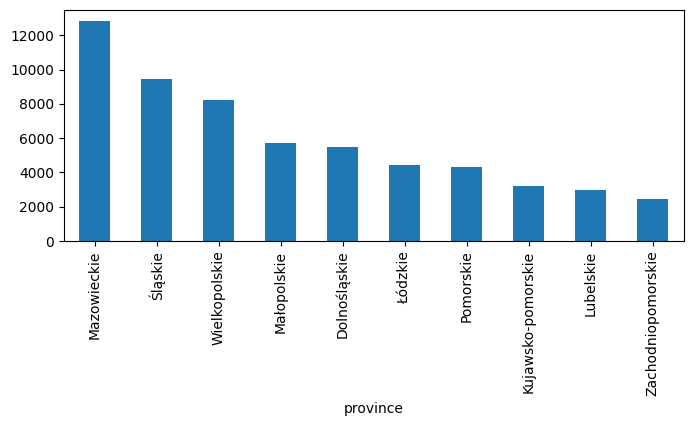

In [23]:
for col in text_columns:
    plt.figure(figsize = (8,3))
    df[col].value_counts(ascending=False).head(10).plot(kind="bar")
    plt.show()

## To check the relation of features with the price

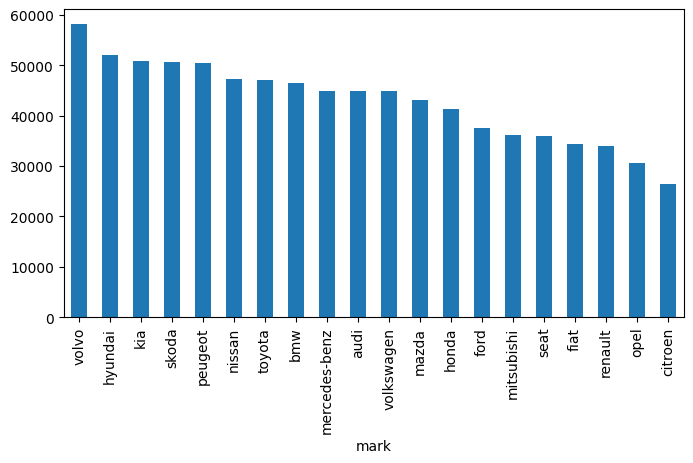

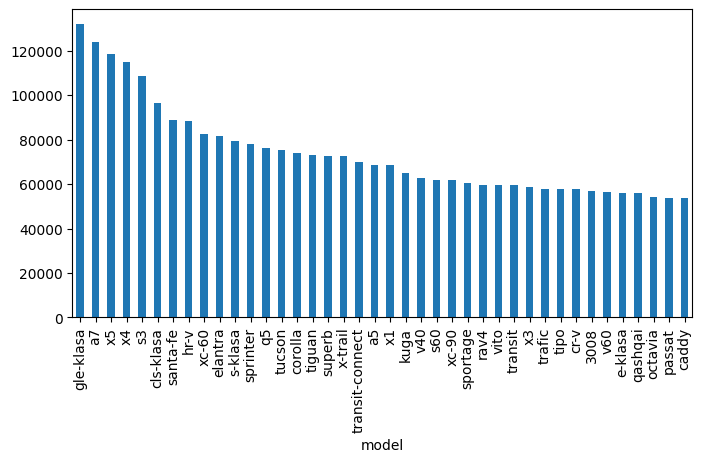

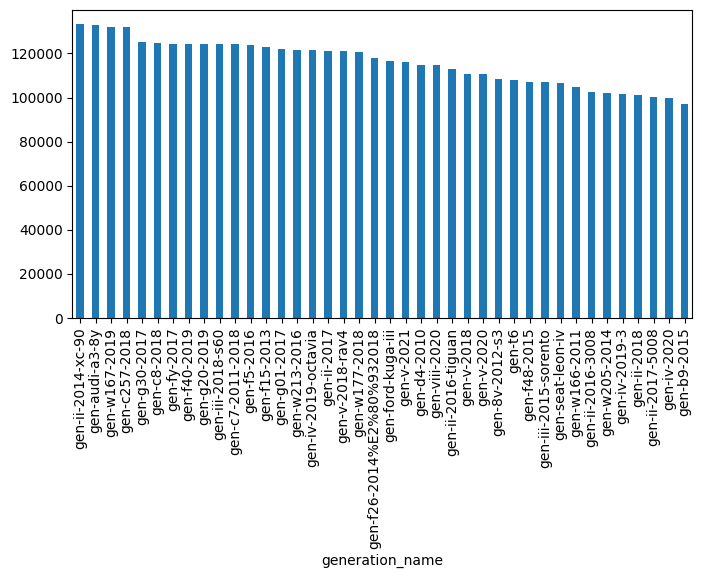

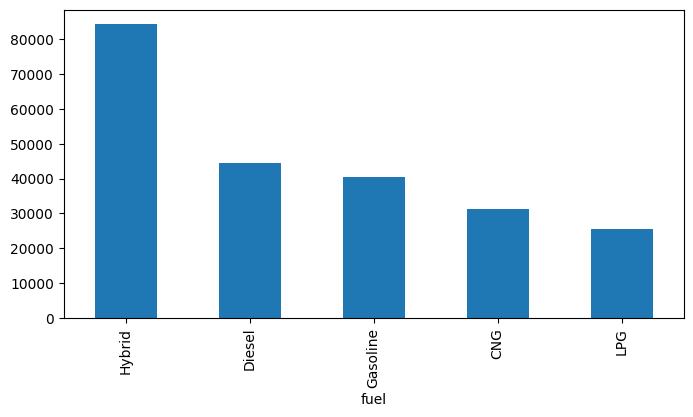

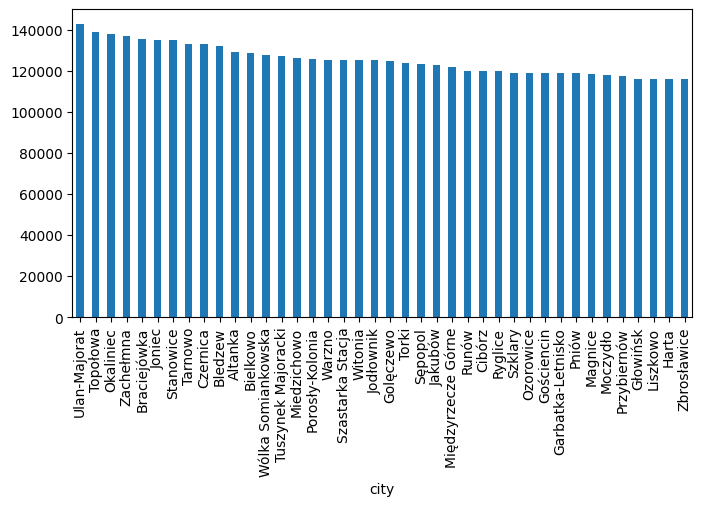

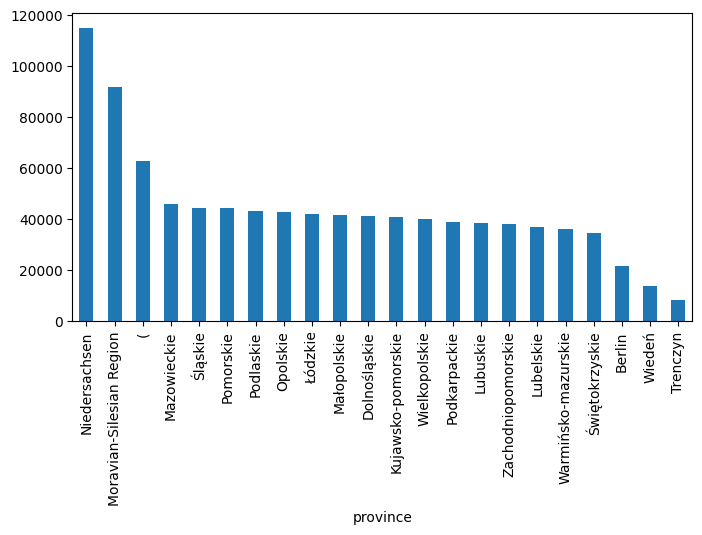

In [24]:

for col in text_columns:
    plt.figure(figsize = (8,4))
    df.groupby(col)["price"].mean().sort_values(ascending=False).head(40).plot(kind="bar")
    plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
scaler = StandardScaler()
le = LabelEncoder()

### to assign the numeric values to text columns

In [26]:

for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

In [27]:
df.corr()

,mark,model,generation_name,year,mileage,vol_engine,fuel,city,province,price
mark,1.000000,0.196819,0.246185,0.121745,-0.117552,-0.227961,0.052916,0.005299,0.001786,0.022738
model,0.196819,1.000000,-0.083408,0.071234,-0.018935,0.064960,-0.076213,-0.004996,-0.001162,0.123390
generation_name,0.246185,-0.083408,1.000000,0.240800,-0.239778,-0.253888,0.073241,0.007266,0.019613,0.100035
year,0.121745,0.071234,0.240800,1.000000,-0.671815,-0.250313,-0.077639,0.018455,0.004956,0.796587
mileage,-0.117552,-0.018935,-0.239778,-0.671815,1.000000,0.427870,-0.198991,-0.020707,-0.025703,-0.590134
vol_engine,-0.227961,0.064960,-0.253888,-0.250313,0.427870,1.000000,-0.300485,0.003427,-0.040087,0.077804
fuel,0.052916,-0.076213,0.073241,-0.077639,-0.198991,-0.300485,1.000000,0.008100,0.007001,-0.083026
city,0.005299,-0.004996,0.007266,0.018455,-0.020707,0.003427,0.008100,1.000000,-0.070049,0.026105
province,0.001786,-0.001162,0.019613,0.004956,-0.025703,-0.040087,0.007001,-0.070049,1.000000,-0.012935
price,0.022738,0.123390,0.100035,0.796587,-0.590134,0.077804,-0.083026,0.026105,-0.012935,1.000000


In [28]:
df.columns

Index(['mark', 'model', 'generation_name', 'year', 'mileage', 'vol_engine',
       'fuel', 'city', 'province', 'price'],
      dtype='object')

## select features for training the models

In [29]:

x = df[['mark','model','generation_name','year','mileage','vol_engine','fuel']]
y = df['price']

In [30]:
#convert the values in the standard form
x = scaler.fit_transform(x)

In [31]:
from sklearn.model_selection import train_test_split,GridSearchCV 

In [32]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [33]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,mean_absolute_percentage_error

In [53]:
# write the function for predicting the result easily
def result(predict):
    print(f"mean_absolute_error is { mean_absolute_error(y_test,predict)}")
    print(f"mean_squared_root_error is { np.sqrt(mean_squared_error(y_test,predict))}")
    print(f"r2_score is {r2_score(y_test,predict)}")
    print(f"{mean_absolute_percentage_error(y_test,predict)}")
    

In [35]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()

In [36]:
dtr.fit(x_train, y_train)

DecisionTreeRegressor()

In [37]:
dtr_pred = dtr.predict(x_test)

In [54]:
result(dtr_pred)

mean_absolute_error is 6373.969412607363
mean_squared_root_error is 10358.384854767222
r2_score is 0.8822934504547341
0.18777992679180663


In [39]:
from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor()

In [40]:
knr.fit(x_train,y_train)

KNeighborsRegressor()

In [41]:
knr_pred = knr.predict(x_test)

In [55]:
result(knr_pred)

mean_absolute_error is 5346.916256044209
mean_squared_root_error is 8453.113191557255
r2_score is 0.9216119407193066
0.15897078937688466


In [43]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()

In [44]:
grid_rfr = {
        
     'random_state': [None, 42],
    'n_estimators': [100,110,120],
}

In [45]:
gsv=GridSearchCV(rfr,grid_rfr, cv=5)

In [46]:
gsv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'n_estimators': [100, 110, 120],
                         'random_state': [None, 42]})

In [47]:
grid_rfr_pred =gsv.predict(x_test)

In [56]:
result(grid_rfr_pred)

mean_absolute_error is 5040.714346060589
mean_squared_root_error is 8040.00448751887
r2_score is 0.9290864665432411
0.1485926172699571


In [49]:
gsv.best_params_

{'n_estimators': 120, 'random_state': 42}

## conclustion
    This is an advanced data science project where we developed an efficient machine learning model to predict used cars prices for one company. Realized an analysis of the main features such as model, generation, year of production, mileage, localization, and the engine types. After outliers removal from numerical parameters, there was an exploring analysis revealing the following: Diesel and petrol engines are the most sold in Poland, at the same time hybrid engines have the highest mean price. Among the brands, the most available is Opel and model – Astra, while for the most expensive model and brand it is Volvo and gle-klasa respectively. The most populated but also high demand would go towards such high-value but also well-known units like Audi A7 and BMW X5. Localization showed that around Warszawa would find the most demand for the cars prices. Just as discovered from the analysis features ‘year’ and ‘mileage’ impact directly on the price more than most categorical variables like ‘generation name’ or ‘model name’. After training and evaluating the results of Decision Tree, K- Neighbors and Random Forest Regression models, it was concluded that Random Forest is the best performer. Mean Absolute Error=5040, Root Mean Squared Error=8040, R-Squared Score=0.929 with Mean Absolute Percentage Error of 14.8%. Detailed results ready to use for stakeholders and optimize pricing mechanism and know the variables that most affect the price among the features detected in the analysis.